In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_training_solutions.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_evaluation_solutions.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_evaluation_challenges.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-2/sample_submission.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_training_challenges.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_test_challenges.json


# ARC AGI 2 Competition
This will be my first time attempting this competition while also documenting my learning process.

In [2]:
# Importing dataset from the competition
import kagglehub

# Download latest version
path = kagglehub.competition_download('arc-prize-2026-arc-agi-2')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/arc-prize-2026-arc-agi-2


So the dataset is unlike other files that I've encountered, instead of a tabular table (csv, xls), its a json file.
- Train pairs: 2 to 5 examples of an input grid and its corresponding output grid.
- Test pairs: 1 or more input grids where the output is hidden, and your system must predict it.

Okay, next let me try to visualise the data to it can help me see the puzzles. First, to visualise, I need to map the numbers (from 0 to 9) to a specific colour pallete.


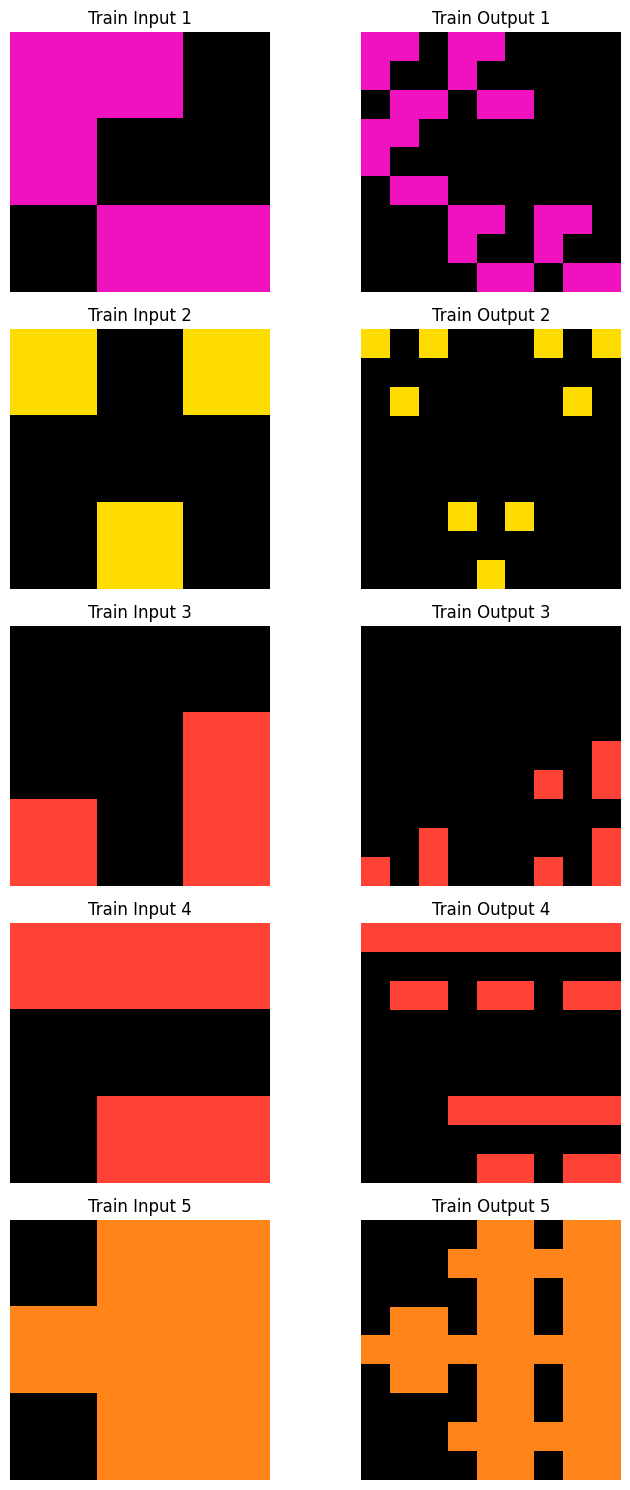

In [3]:
import json
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np

# defining official ARC colour palette
arc_hex_colors = [
    '#000000', # 0: Black (Background)
    '#0074D9', # 1: Blue
    '#FF4136', # 2: Red
    '#2ECC40', # 3: Green
    '#FFDC00', # 4: Yellow
    '#AAAAAA', # 5: Grey
    '#F012BE', # 6: Magenta/Fuchsia
    '#FF851B', # 7: Orange
    '#7FDBFF', # 8: Cyan/Teal
    '#870C25'  # 9: Brown
]

# Create the matplotlib colormap
cmap = colors.ListedColormap(arc_hex_colors)
norm = colors.Normalize(vmin=0, vmax=9) # here lock the int 0 to first col and 1 to the second (blue)

def plot_arc_task_from_collection(file_path, task_id):
    """
    Loads the master ARC JSON collection and plots a specific task by its ID.
    """
    # STEP 1: Load the massive master file (arc-agi_training_challenges.json)
    # 'f' is just a temporary variable representing the opened file.
    with open(file_path, 'r') as f:
        all_tasks = json.load(f)
        
    # STEP 2: Safety Check. Ensure the ID we asked for actually exists in the file.
    if task_id not in all_tasks:
        print(f"Error: Task ID '{task_id}' not found in the dataset.")
        return
        
    # STEP 3: Extract just the specific puzzle dictionary we want
    task = all_tasks[task_id]
    train_pairs = task['train']
    num_pairs = len(train_pairs)

    # STEP 4: Set up the plotting grid
    fig, axes = plt.subplots(num_pairs, 2, figsize=(8, 3 * num_pairs))

    # STEP 5: Loop through and draw each pair
    for i, pair in enumerate(train_pairs):
        input_grid = pair['input']
        output_grid = pair['output']
        
        # Draw the Input (Left Column)
        axes[i, 0].imshow(input_grid, cmap=cmap, norm=norm)
        axes[i, 0].set_title(f'Train Input {i+1}')
        axes[i, 0].axis('off') 
        
        # Draw the Output (Right Column)
        axes[i, 1].imshow(output_grid, cmap=cmap, norm=norm)
        axes[i, 1].set_title(f'Train Output {i+1}')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

kaggle_master_file = '/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_training_challenges.json'

# Here is a specific Task ID from the file you uploaded to test it out:
sample_puzzle_id = '007bbfb7'

# Execute the function!
plot_arc_task_from_collection(kaggle_master_file, sample_puzzle_id)

Output explaination: the goal is to find the single, consistent rule that transforms every left-side grid (the input) into its corresponding right-side grid (the output). The AI system you eventually build will need to figure this out automatically.
- The input grid here is a 3x3 where the output grid is exactly 9x9
- That would mean the output grid is multiplied by the initial input grid by 3. This is the scale factor, which also means the every single 1x1 input grid is expanded into a 3x3 block of pixel.
- In the blank space of the output grid us where the input is 0. Moreover, the output has the exact shape of the input grid. This is called Kronecker Transformation (Fractal Transformation)
- Meaning everytime there is a coloured pixel (Train input 1 grid 6), it expands into a full identical copy of the entire 3x3 input grid
- Every time there is a black pixel (0) in the input grid, it expands into a completely empty 3x3 block of zeros.

In [4]:
import numpy as np

def solve_fractal_puzzle(input_grid):
    """
    Automates the fractal transformation where each colored pixel 
    in the input expands into a full copy of the input grid.
    """
    # 1. Convert the input list into a NumPy array so we can manipulate it easily
    input_array = np.array(input_grid)
    
    # 2. Get the dimensions of the input (in this case, h=3, w=3)
    h, w = input_array.shape
    
    # 3. Create our blank canvas. 
    # Since scale factor is 3, output is h*3 by w*3 (9x9)
    # np.zeros creates an array filled entirely with 0s.
    output_array = np.zeros((h * h, w * w), dtype=int)
    
    # 4. Loop through every single cell in the original input grid
    for i in range(h):
        for j in range(w):
            
            # 5. Check the rule: Is this pixel colored?
            if input_array[i, j] != 0:
                
                # Calculate exactly where the stamp should go on the 9x9 canvas
                row_start = i * h
                row_end = row_start + h
                
                col_start = j * w
                col_end = col_start + w
                
                # 6. Apply the stamp! Paste the original input array into this block
                output_array[row_start:row_end, col_start:col_end] = input_array
                
    # Convert it back to a standard Python list to match the ARC JSON format
    return output_array.tolist()

# --- LET'S TEST IT ---
# Here is the raw data from "Train Input 1" of our puzzle
test_input = [
    [6, 6, 0],
    [6, 0, 0],
    [0, 6, 6]
]

# Run our function
predicted_output = solve_fractal_puzzle(test_input)

# Print the results nicely
print("Our Predicted Output:")
for row in predicted_output:
    print(row)

Our Predicted Output:
[6, 6, 0, 6, 6, 0, 0, 0, 0]
[6, 0, 0, 6, 0, 0, 0, 0, 0]
[0, 6, 6, 0, 6, 6, 0, 0, 0]
[6, 6, 0, 0, 0, 0, 0, 0, 0]
[6, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 6, 6, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 6, 6, 0, 6, 6, 0]
[0, 0, 0, 6, 0, 0, 6, 0, 0]
[0, 0, 0, 0, 6, 6, 0, 6, 6]


I've realised that if I were to do this using Python lists, the stamping set would require writing complex loops within loops just to append numbers correctly. 

By converting the grid to a numpy array, we unlocked "array slicing". The line "output_array[row_start:row_end, col_start:col_end] = input_array" tells python to carve out a 3x3 square on our blank canvas and drop the entire input grid into one clean move. 

In the output above, we can see that it matches the image in output train 1, where if theres numbers of 6 in the predicted canvas, the output train 1 has the orange image as well

Now the next step is to create evaluation on the test set. To prove that our logic is correct, the rule must apply to every single train set example in the task. 

Building an evaluation pipeline is the next step to validate my solver. Since ARC require absolute perfection, where a single incorrect pixel means the whole prediction is wrong, my evaluation metric is an exact match,

The logical breakdown of my evaluator would be:
- **Iterate**: Loop through every dictionary inside the train list
- **Extract**: Grab the `input` and the expected `output` for that specific pair
- **Predict**: Pass the `input` into our `solve_fractal_puzzle` function
- **Compare**: Check if our generated list perfectly matches the expected output list
- **Score**: Tally the results and print a clea report

In [7]:
def evaluate_task(task_data, solver_function):
    """
    Runs a solver function against all training pairs in a task 
    and verifies if the predictions are 100% correct.
    """
    train_pairs = task_data['train']
    total_pairs = len(train_pairs)
    correct_count = 0
    
    print("--- Starting Evaluation ---")
    
    # 1. Loop through each training pair
    for i, pair in enumerate(train_pairs):
        input_grid = pair['input']
        expected_output = pair['output']
        
        # 2. Generate our prediction using the function we built
        predicted_output = solver_function(input_grid)
        
        # 3. Compare prediction to the ground truth
        if predicted_output == expected_output:
            print(f"Example {i+1}: ✅ PASS")
            correct_count += 1
        else:
            print(f"Example {i+1}: ❌ FAIL")
            
    # 4. Print final score
    print(f"\nFinal Score: {correct_count}/{total_pairs} Correct")
    
    # Return True if we solved every single pair perfectly
    return correct_count == total_pairs

# --- FIX: Load the file globally first ---
import json

kaggle_master_file = '/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_training_challenges.json'

# Open and load the full dictionary into 'all_tasks'
with open(kaggle_master_file, 'r') as f:
    all_tasks = json.load(f)

# Select our target task
task_id = '007bbfb7'
current_task = all_tasks[task_id]

# Run the evaluator!
passed_all = evaluate_task(current_task, solve_fractal_puzzle)

--- Starting Evaluation ---
Example 1: ✅ PASS
Example 2: ✅ PASS
Example 3: ✅ PASS
Example 4: ✅ PASS
Example 5: ✅ PASS

Final Score: 5/5 Correct


Now that Ive gotten all pass meaning that it has captured the pattern for every single training set that we have. In the ARC dataset, each task has a `test` list that contain the input grid but no output grid. In the beginning, the dictionary has two main keys:
- `'train'`: A list of pairs that have both an `'input'` and an `'output'`
- `'test'`: A list that only gives us the `'input'`

In [8]:
# 1. Access the first (and usually only) item in the 'test' list
test_item = current_task['test'][0]

# 2. Extract the raw input grid
test_input_grid = test_item['input']

# 3. Run it through our verified solver!
final_test_prediction = solve_fractal_puzzle(test_input_grid)

print("Test Case Solved! Generated a prediction with dimensions:", 
      len(final_test_prediction), "x", len(final_test_prediction[0]))

Test Case Solved! Generated a prediction with dimensions: 9 x 9


Plotting a graph to visually compare the rule applied to the training data vs how my model applied to the test data, so the below is a 2x2 visual grid.

The top row wil display the first Train pair as a baseline reference, and the bottom row will display the Test input right next to the prediction my code just generated.

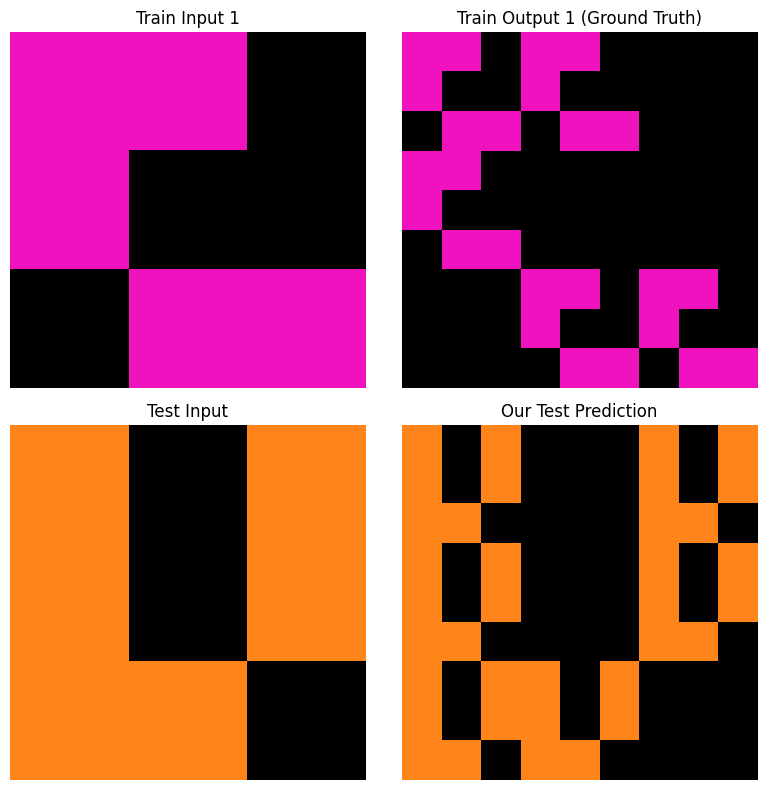

In [9]:
# Ensure our ARC colors are defined
arc_hex_colors = ['#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00', 
                  '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870C25']
cmap = colors.ListedColormap(arc_hex_colors)
norm = colors.Normalize(vmin=0, vmax=9)

def plot_train_vs_test_prediction(task_data, test_prediction):
    """
    Plots the first Train pair (Input/Output) above the 
    Test pair (Input/Our Prediction) for visual comparison.
    """
    # Set up a 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    
    # --- TOP ROW: TRAIN ---
    train_input = task_data['train'][0]['input']
    train_output = task_data['train'][0]['output']
    
    axes[0, 0].imshow(train_input, cmap=cmap, norm=norm)
    axes[0, 0].set_title('Train Input 1')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(train_output, cmap=cmap, norm=norm)
    axes[0, 1].set_title('Train Output 1 (Ground Truth)')
    axes[0, 1].axis('off')
    
    # --- BOTTOM ROW: TEST ---
    test_input = task_data['test'][0]['input']
    
    axes[1, 0].imshow(test_input, cmap=cmap, norm=norm)
    axes[1, 0].set_title('Test Input')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(test_prediction, cmap=cmap, norm=norm)
    axes[1, 1].set_title('Our Test Prediction')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# --- LET'S RUN IT ---
# We pass in the full task dictionary and the prediction list we generated in the last step
plot_train_vs_test_prediction(current_task, final_test_prediction)

In the visuals, the test inout grid has its own layout of coloured pixel and the code correctly scaled up into a 9x9 matrix following the exact rule.

Explanation about Kronecker product: In mathematics and computer science, this specific pattern-stamping behavior is known as a Kronecker product (often denoted by the symbol $\otimes$) or a matrix fractal. Every element in the first matrix is multiplied by the entire second matrix. Here, the grid is multiplied by itself!
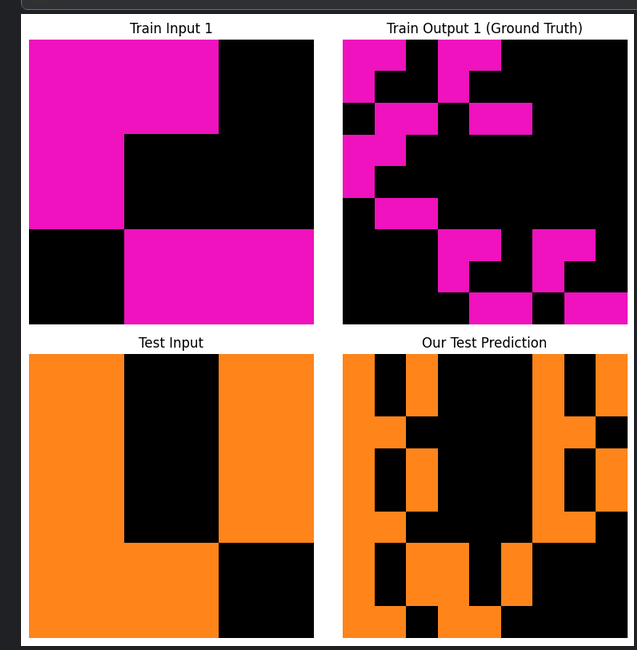
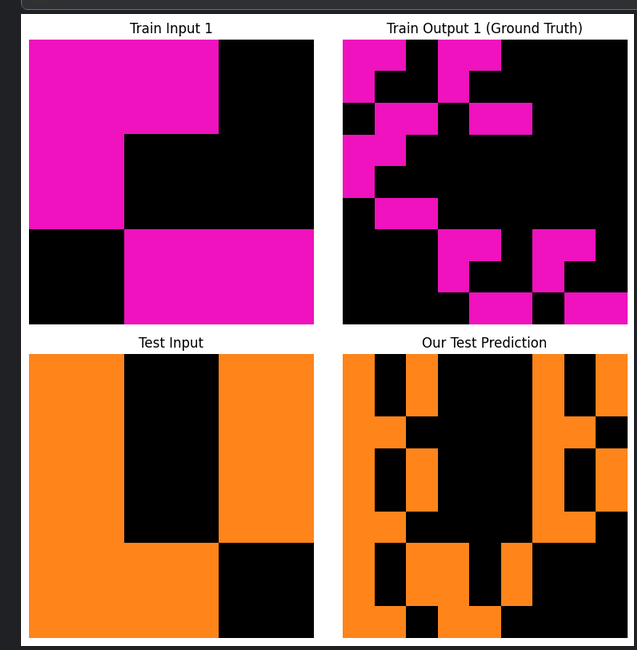

Earlier, in the previous section, I have hardcoded solver for a single task, now I have to find a way to automate all 400 tasks for a AGI system. 

After my research, there are two ways of automating the process:
- **Domain-Specific Language (DSL) & Program Synthesis**: Building a primitive function like (`rotate`, `scale`, `repeat_pattern`, `fill_color`) and using a search algorithm to automatically combine them until a program passses the training cases.
- **Deep learning/LLM solvers**: Using LLM with the grid coordinates or utilising a vision-based architecture to predict the code or the grid transformation directly.

Some of the pros and cons for these two models:
- **DSL**: This approach is 100% accurate if it works. But if the DSL doesnt have a specific rule programmed to it, it will completely fail to solve the puzzles.
- **LLM**: Quite flexible and can guess the underlying logic easily, but they struggle with exact spatial math. For example, they might correctly identify "the blue box moves right", but accidently place it one pixel to far.